# XAI + GNN Compatibility Test Notebook

End-to-end test of all XAI methods (MolAnchor, MolCE, Counterfactuals) on both
sklearn (RFC) and all supported GNN architectures (GCN, GraphSAGE, GAT, GC_GNN, GIN).

## Sections
1. Setup & data loading
2. Featurization & splitting
3. Train RFC (sklearn)
4. Train all GNN types
5. MolAnchor — single instance (all models)
6. MolAnchor — recurrent rules (all models)
7. MolCE — single instance (all models)
8. MolCE — recurrent rules (all models)
9. Counterfactuals — 3 test instances (all models)

---
## 1 — Setup

In [1]:
import sys
from pathlib import Path

_ws_root = Path.cwd()
if not (_ws_root / "src").exists():
    _ws_root = _ws_root.parent
if str(_ws_root / "src") not in sys.path:
    sys.path.insert(0, str(_ws_root / "src"))

print(f"Workspace root: {_ws_root}")

Workspace root: c:\Users\lamens\projects\AI_agent\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability


In [2]:
import json
import time
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline

from IPython.display import display, Image as IPyImage
from rdkit import Chem
from rdkit.Chem import Draw

print("Imports OK")

Imports OK


---
## 2 — Load dataset, featurize, and split

In [3]:
from chemagent.datasets.loader import load_csv
from chemagent.datasets.featurizer import featurize_df, build_processed_entry
from chemagent.datasets.splitter import split_processed, save_split

DATASET_PATH = str(_ws_root / "data/datasets/chembl_activity_data_O00329_P42336.csv")
DATASET_ID = "chembl_activity_data_O00329_P42336"

N_BITS = 2048
RADIUS = 2

df, meta = load_csv(DATASET_PATH, label_col="class_label", smiles_col="smiles", id_col="cid")
print(f"Loaded {len(df)} compounds, classes: {sorted(df['class_label'].unique())}")

Loaded 1195 compounds, classes: [np.int64(0), np.int64(1), np.int64(2)]


In [4]:
# Featurize (ECFP) with bit info for MolAnchor
features, bit_info = featurize_df(df, method="ECFP", n_bits=N_BITS, radius=RADIUS, return_bit_info=True)
print(f"Feature matrix shape: {features.shape}")
print(f"Bit info entries: {len(bit_info) if bit_info else 0}")

Feature matrix shape: (1195, 2048)
Bit info entries: 62


In [5]:
# Build processed entry and split
processed = build_processed_entry(df, features, label_col="class_label", smiles_col="smiles", id_col="cid", bit_info=bit_info)

split_result = split_processed(
    processed,
    split_type="random",
    train_size=0.7, val_size=0.1, test_size=0.2,
    seed=42, stratified=True,
)

# Save split
OUT_DIR = _ws_root / "notebooks" / "debug_outputs" / "xai_gnn_test"
OUT_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_PATH = str(OUT_DIR / f"{DATASET_ID}_random.pkl")
joblib.dump(split_result["save_dict"], SPLIT_PATH)

split_data = split_result["save_dict"]
print(f"Split saved to: {SPLIT_PATH}")
print(f"Train: {len(split_data['train_labels'])}, Val: {len(split_data['val_labels'])}, Test: {len(split_data['test_labels'])}")
print(f"Split keys: {list(split_data.keys())}")

Split saved to: c:\Users\lamens\projects\AI_agent\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\notebooks\debug_outputs\xai_gnn_test\chembl_activity_data_O00329_P42336_random.pkl
Train: 836, Val: 120, Test: 239
Split keys: ['train_labels', 'val_labels', 'test_labels', 'train_features', 'val_features', 'test_features', 'train_smiles', 'val_smiles', 'test_smiles', 'train_cid', 'val_cid', 'test_cid']


In [6]:
# Save bit info for MolAnchor
BIT_INFO_PATH = str(OUT_DIR / f"{DATASET_ID}_bit_info.pkl")
if bit_info:
    joblib.dump(bit_info, BIT_INFO_PATH)
    print(f"Bit info saved to: {BIT_INFO_PATH}")
else:
    BIT_INFO_PATH = None
    print("No bit info available")

Bit info saved to: c:\Users\lamens\projects\AI_agent\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\notebooks\debug_outputs\xai_gnn_test\chembl_activity_data_O00329_P42336_bit_info.pkl


---
## 3 — Train RFC (sklearn)

In [7]:
from chemagent.ml.training import MLModel
from chemagent.ml.evaluation import Model_Evaluation

# Build a simple data container for MLModel
class _DataContainer:
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels
        self.class_labels = sorted(set(labels))

train_data = _DataContainer(
    features=np.array(split_data["train_features"]),
    labels=np.array(split_data["train_labels"]),
)

t0 = time.time()
ml = MLModel(train_data, ml_algorithm="RFC", opt_metric="balanced_accuracy", reg_class="classification")
print(f"RFC trained in {time.time() - t0:.1f}s")
print(f"Best params: {ml.best_params}")

# Save
RFC_MODEL_PATH = str(OUT_DIR / f"{DATASET_ID}_RFC.pkl")
joblib.dump(ml.model, RFC_MODEL_PATH)
print(f"RFC saved to: {RFC_MODEL_PATH}")

RFC trained in 21.6s
Best params: {'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
RFC saved to: c:\Users\lamens\projects\AI_agent\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\notebooks\debug_outputs\xai_gnn_test\chembl_activity_data_O00329_P42336_RFC.pkl


In [9]:
# Quick test-set accuracy
rfc_preds = ml.model.predict(np.array(split_data["test_features"]))
rfc_acc = np.mean(rfc_preds == np.array(split_data["test_labels"]))
print(f"RFC test accuracy: {rfc_acc:.3f}")

RFC test accuracy: 0.933


---
## 4 — Train all GNN types

In [10]:
from chemagent.ml.gnn_models import GCN, GraphSAGE, GAT, GC_GNN, GIN
from chemagent.ml.gnn_training import train_gnn_model

GNN_CLASSES = {
    "GCN": GCN,
    "GraphSAGE": GraphSAGE,
    "GAT": GAT,
    "GC_GNN": GC_GNN,
    "GIN": GIN,
}

# Common training params — keep epochs low for testing speed
GNN_EPOCHS = 30
GNN_HIDDEN = 64
GNN_LAYERS = 4

smiles_list = list(df["smiles"])

gnn_model_paths = {}  # name -> path
gnn_results = {}      # name -> result dict

for name, cls in GNN_CLASSES.items():
    save_path = str(OUT_DIR / f"{DATASET_ID}_{name}.pt")
    print(f"\n{'='*60}")
    print(f"Training {name}...")
    t0 = time.time()
    
    result = train_gnn_model(
        split_file_path=SPLIT_PATH,
        smiles_list=smiles_list,
        model_class=cls,
        model_save_path=save_path,
        hidden_channels=GNN_HIDDEN,
        num_layers=GNN_LAYERS,
        epochs=GNN_EPOCHS,
    )
    
    elapsed = time.time() - t0
    gnn_model_paths[name] = save_path
    gnn_results[name] = result
    print(f"{name} done in {elapsed:.1f}s | best_val_acc={result['best_val_acc']:.3f} | test_acc={result['test_acc']:.3f}")

print(f"\n{'='*60}")
print("All GNN models trained.")


Training GCN...


  0%|          | 0/30 [00:00<?, ?it/s]

GCN done in 7.6s | best_val_acc=0.845 | test_acc=0.845

Training GraphSAGE...


  0%|          | 0/30 [00:00<?, ?it/s]

GraphSAGE done in 5.9s | best_val_acc=0.845 | test_acc=0.845

Training GAT...


...

GAT done in 11.2s | best_val_acc=0.857 | test_acc=0.837

Training GC_GNN...


  0%|          | 0/30 [00:00<?, ?it/s]

GC_GNN done in 6.9s | best_val_acc=0.917 | test_acc=0.828

Training GIN...


  0%|          | 0/30 [00:00<?, ?it/s]

GIN done in 7.8s | best_val_acc=0.952 | test_acc=0.916

All GNN models trained.


In [11]:
# Summary table
summary_rows = []
for name, result in gnn_results.items():
    summary_rows.append({
        "model": name,
        "best_val_acc": round(result["best_val_acc"], 3),
        "test_acc": round(result["test_acc"], 3),
        "n_train": result["n_train"],
        "n_val": result["n_val"],
        "n_test": result["n_test"],
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,model,best_val_acc,test_acc,n_train,n_val,n_test
0,GCN,0.845,0.845,668,168,239
1,GraphSAGE,0.845,0.845,668,168,239
2,GAT,0.857,0.837,668,168,239
3,GC_GNN,0.917,0.828,668,168,239
4,GIN,0.952,0.916,668,168,239


---
## 5 — MolAnchor: single instance (all models)

Pick one correctly predicted test compound per model and run `explain_with_molanchor`.

In [12]:
from chemagent.explainability.molanchor_tools import (
    _explain_with_molanchor,
    select_compound_for_xai,
    identify_recurrent_anchor_rules,
)

# Determine num_classes from split labels
NUM_CLASSES = len(set(split_data["train_labels"]) | set(split_data["val_labels"]) | set(split_data["test_labels"]))
print(f"Number of classes: {NUM_CLASSES}")

Number of classes: 3


MolAnchor single instance — RFC
Selected: idx=71, SMILES=Cc1cc(N2CCOc3cnc(OC4CCN(C(=O)C5CCOCC5)C4)cc32)cnc1S(C)(=O)=O...
  Predicted=1, Confidence=0.780
anchors identified = ['frag_0', 'frag_3', 'frag_5'], num fragments = 6, plural_rule = True, Precision = [1.0], Coverage = [0.13]
  Anchor SMILES: ['[*]c1cnc(S(C)(=O)=O)c(C)c1', '[*]N1CCC([*])C1', '[*]C1CCOCC1']
  Precision: 1.0
  Status: completed


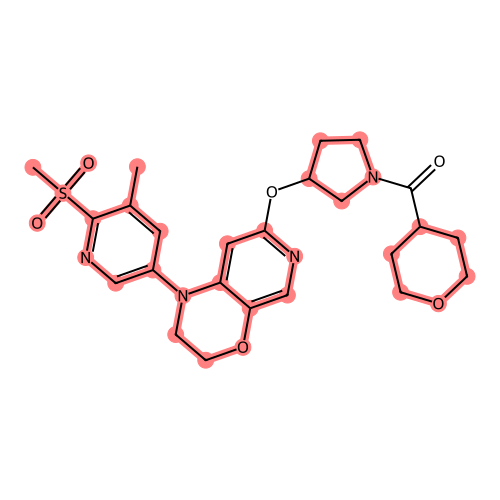

In [13]:
# --- RFC ---
print("=" * 60)
print("MolAnchor single instance — RFC")
print("=" * 60)

rfc_compound = select_compound_for_xai(
    split_file_path=SPLIT_PATH,
    model_path=RFC_MODEL_PATH,
    target_class=1,
    split="test",
    seed=42,
)
print(f"Selected: idx={rfc_compound['index']}, SMILES={rfc_compound['smiles'][:60]}...")
print(f"  Predicted={rfc_compound['predicted_label']}, Confidence={rfc_compound['prediction_confidence']:.3f}")

# Do NOT pass bit_info_path or original_fp_path here — the dataset-level bit_info
# describes a different molecule's atom environments. _explain_with_molanchor
# computes per-compound bit_info and original_fp automatically when omitted.
rfc_anchor_result, rfc_mol_anchor = _explain_with_molanchor(
    smiles=rfc_compound["smiles"],
    model_path=RFC_MODEL_PATH,
    representation="ECFP",
    target_class=1,
    n_bits=N_BITS,
    radius=RADIUS,
)
print(f"  Anchor SMILES: {rfc_anchor_result.get('anchor_smiles')}")
print(f"  Precision: {rfc_anchor_result.get('precision')}")
print(f"  Status: {rfc_anchor_result.get('status')}")

# Visualize
anchor_idx = rfc_anchor_result.get("anchor_indices", [])
if anchor_idx and rfc_mol_anchor is not None:
    img = rfc_mol_anchor.map_anchor_to_cpd(anchor_idx)
    display(img)


MolAnchor single instance — GCN
Selected: idx=118, SMILES=COc1ncc(-c2ccc3c(c2)COC3)cc1NS(C)(=O)=O...
  Predicted=0, Confidence=0.705
All fragments anchor
  Anchor SMILES: ['all_frags']
  Precision: 0.0
  Status: completed

MolAnchor single instance — GraphSAGE
Selected: idx=118, SMILES=COc1ncc(-c2ccc3c(c2)COC3)cc1NS(C)(=O)=O...
  Predicted=0, Confidence=0.802
anchors identified = {'frag_0'}, num fragments = 5, plural_rule = False, Precision = [1.0], Coverage = [0.52]
  Anchor SMILES: ['[*]OC']
  Precision: 1.0
  Status: completed


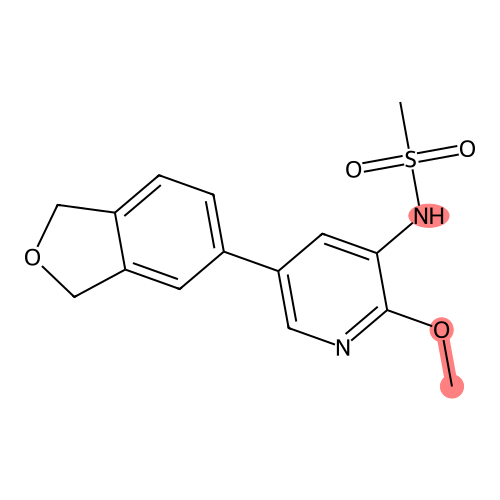


MolAnchor single instance — GAT
Selected: idx=123, SMILES=Cc1nc(N)nc(-n2c(Nc3n[nH]c4ccccc34)nc3ccccc32)n1...
  Predicted=0, Confidence=0.819
anchors identified = {'frag_1'}, num fragments = 4, plural_rule = False, Precision = [1.0], Coverage = [0.53]
  Anchor SMILES: ['[*]n1c([*])nc2ccccc21']
  Precision: 1.0
  Status: completed


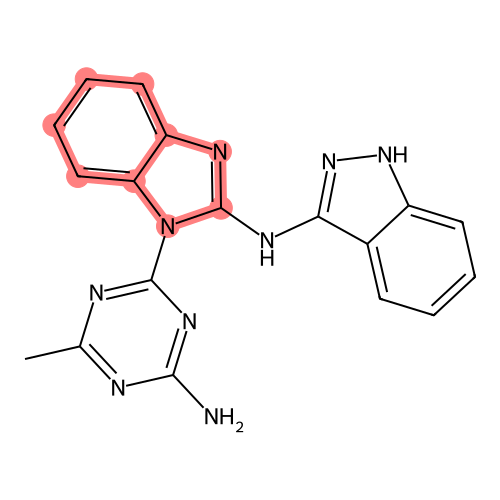


MolAnchor single instance — GC_GNN
Selected: idx=130, SMILES=O=C(Cc1nc(N2CCOCC2)cc(=O)[nH]1)Nc1ccc(Cl)cc1...
  Predicted=0, Confidence=0.793
anchors identified = {'frag_1'}, num fragments = 5, plural_rule = False, Precision = [1.0], Coverage = [0.52]
  Anchor SMILES: ['[*]c1cc(=O)[nH]c([*])n1']
  Precision: 1.0
  Status: completed


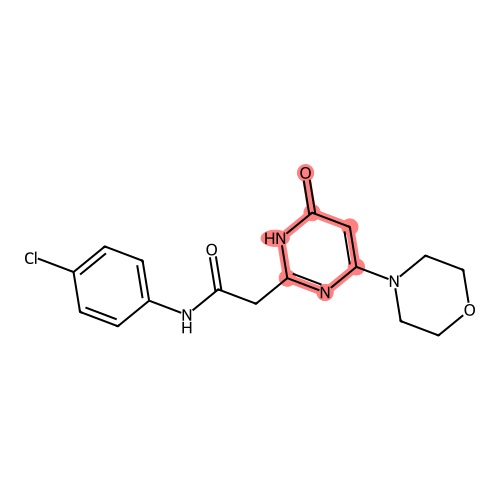


MolAnchor single instance — GIN
Selected: idx=120, SMILES=CC(=O)Nc1ncc(-c2nc(N3CCOCC3)c3ncccc3n2)cn1...
  Predicted=0, Confidence=1.000
anchors identified = {'frag_0'}, num fragments = 5, plural_rule = False, Precision = [1.0], Coverage = [0.52]
  Anchor SMILES: ['[*]C(C)=O']
  Precision: 1.0
  Status: completed


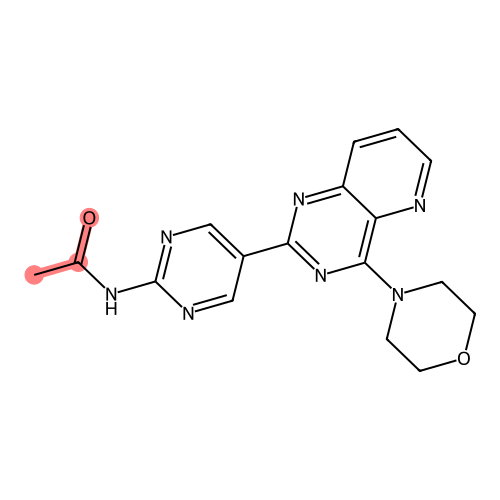

In [14]:
# --- All GNN models ---
gnn_anchor_results = {}

for gnn_name, gnn_path in gnn_model_paths.items():
    print(f"\n{'=' * 60}")
    print(f"MolAnchor single instance — {gnn_name}")
    print("=" * 60)
    
    try:
        compound = select_compound_for_xai(
            split_file_path=SPLIT_PATH,
            model_path=gnn_path,
            target_class=0,
            split="test",
            seed=42,
            gnn_model_class_name=gnn_name,
            gnn_hidden_channels=GNN_HIDDEN,
            gnn_num_classes=NUM_CLASSES,
        )
        print(f"Selected: idx={compound['index']}, SMILES={compound['smiles'][:60]}...")
        print(f"  Predicted={compound['predicted_label']}, Confidence={compound['prediction_confidence']:.3f}")
        
        result, mol_anchor = _explain_with_molanchor(
            smiles=compound["smiles"],
            model_path=gnn_path,
            representation="graphs",
            target_class=0,
            gnn_model_class_name=gnn_name,
            gnn_hidden_channels=GNN_HIDDEN,
            gnn_num_classes=NUM_CLASSES,
        )
        print(f"  Anchor SMILES: {result.get('anchor_smiles')}")
        print(f"  Precision: {result.get('precision')}")
        print(f"  Status: {result.get('status')}")
        gnn_anchor_results[gnn_name] = result
        
        anchor_idx = result.get("anchor_indices", [])
        if anchor_idx and mol_anchor is not None:
            img = mol_anchor.map_anchor_to_cpd(anchor_idx)
            display(img)
    except Exception as e:
        print(f"  ERROR: {e}")
        gnn_anchor_results[gnn_name] = {"status": "failed", "error": str(e)}

---
## 6 — MolAnchor: recurrent rules (all models)

In [15]:
# --- RFC recurrent anchors ---
print("=" * 60)
print("MolAnchor recurrent rules — RFC")
print("=" * 60)

rfc_recurrent = identify_recurrent_anchor_rules(
    split_file_path=SPLIT_PATH,
    model_path=RFC_MODEL_PATH,
    target_class=1,
    split="test",
    representation="ECFP",
    n_bits=N_BITS,
    radius=RADIUS,
    top_n_anchors=3,
)

# Parse results (list of interleaved MCPImage / json strings)
for item in rfc_recurrent:
    if isinstance(item, str):
        parsed = json.loads(item)
        if "rank" in parsed:
            print(f"  Rule #{parsed['rank']}: {parsed['fragment']} | "
                  f"anchor_occ={parsed['anchor_occurrence']:.2%} | "
                  f"substr_occ={parsed['substructure_occurrence']:.2%}")
        elif "status" in parsed:
            print(f"  Summary: {parsed['status']}, "
                  f"analyzed={parsed.get('num_analyzed_compounds')}, "
                  f"unique_rules={parsed.get('total_unique_anchor_rules')}")
    else:
        # MCPImage — display the underlying PIL image if available
        if hasattr(item, 'path') and Path(item.path).exists():
            display(IPyImage(filename=str(item.path)))

MolAnchor recurrent rules — RFC
anchors identified = ['frag_1', 'frag_3', 'frag_5'], num fragments = 6, plural_rule = True, Precision = [1.0], Coverage = [0.13]
anchors identified = ['frag_2', 'frag_3'], num fragments = 6, plural_rule = True, Precision = [1.0], Coverage = [0.25]
anchors identified = ['frag_0', 'frag_2', 'frag_3'], num fragments = 6, plural_rule = True, Precision = [1.0], Coverage = [0.13]
anchors identified = ['frag_0', 'frag_1'], num fragments = 5, plural_rule = True, Precision = [1.0], Coverage = [0.26]
anchors identified = ['frag_2', 'frag_3'], num fragments = 5, plural_rule = True, Precision = [1.0], Coverage = [0.26]
anchors identified = ['frag_2', 'frag_3'], num fragments = 5, plural_rule = True, Precision = [1.0], Coverage = [0.26]
anchors identified = ['frag_0', 'frag_3', 'frag_5'], num fragments = 6, plural_rule = True, Precision = [1.0], Coverage = [0.13]
anchors identified = ['frag_0', 'frag_3', 'frag_5'], num fragments = 6, plural_rule = True, Precision = [

In [17]:
# --- GNN recurrent anchors ---
gnn_recurrent_results = {}

for gnn_name, gnn_path in gnn_model_paths.items():
    print(f"\n{'=' * 60}")
    print(f"MolAnchor recurrent rules — {gnn_name}")
    print("=" * 60)
    
    try:
        result = identify_recurrent_anchor_rules(
            split_file_path=SPLIT_PATH,
            model_path=gnn_path,
            target_class=0,
            split="test",
            representation="graphs",
            top_n_anchors=3,
            gnn_model_class_name=gnn_name,
            gnn_hidden_channels=GNN_HIDDEN,
            gnn_num_classes=NUM_CLASSES,
        )
        gnn_recurrent_results[gnn_name] = result
        
        for item in result:
            if isinstance(item, str):
                parsed = json.loads(item)
                if "rank" in parsed:
                    print(f"  Rule #{parsed['rank']}: {parsed['fragment']} | "
                          f"anchor_occ={parsed['anchor_occurrence']:.2%} | "
                          f"substr_occ={parsed['substructure_occurrence']:.2%}")
                elif "status" in parsed:
                    print(f"  Summary: {parsed['status']}, "
                          f"analyzed={parsed.get('num_analyzed_compounds')}, "
                          f"unique_rules={parsed.get('total_unique_anchor_rules')}")
            else:
                if hasattr(item, 'path') and Path(item.path).exists():
                    display(IPyImage(filename=str(item.path)))
    except Exception as e:
        print(f"  ERROR: {e}")
        gnn_recurrent_results[gnn_name] = {"status": "failed", "error": str(e)}


MolAnchor recurrent rules — GCN
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
anchors identified = {

[11:34:07] SMARTS Parse Error: syntax error while parsing: all_frags
[11:34:07] SMARTS Parse Error: check for mistakes around position 2:
[11:34:07] all_frags
[11:34:07] ~^
[11:34:07] SMARTS Parse Error: Failed parsing SMARTS 'all_frags' for input: 'all_frags'


anchors identified = {'frag_0'}, num fragments = 4, plural_rule = False, Precision = [1.0], Coverage = [0.53]
anchors identified = {'frag_0'}, num fragments = 5, plural_rule = False, Precision = [1.0], Coverage = [0.52]
anchors identified = {'frag_0'}, num fragments = 5, plural_rule = False, Precision = [1.0], Coverage = [0.52]
  Rule #1: [*]CC | anchor_occ=0.50% | substr_occ=97.52%
  Rule #2: [*]OC | anchor_occ=0.50% | substr_occ=78.22%
  Rule #3: [*]C(=O)CC | anchor_occ=0.50% | substr_occ=17.33%
  Summary: completed, analyzed=202, unique_rules=7

MolAnchor recurrent rules — GraphSAGE
All fragments anchor
anchors identified = {'frag_0'}, num fragments = 4, plural_rule = False, Precision = [1.0], Coverage = [0.53]
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
All fragments anchor
anchors identified = {'frag_0'}, num fragments = 4, plural_rule = False, Precision = [1.0], Coverage = [0.53]
All fragments ancho

[11:34:26] SMARTS Parse Error: syntax error while parsing: all_frags
[11:34:26] SMARTS Parse Error: check for mistakes around position 2:
[11:34:26] all_frags
[11:34:26] ~^
[11:34:26] SMARTS Parse Error: Failed parsing SMARTS 'all_frags' for input: 'all_frags'


anchors identified = {'frag_0'}, num fragments = 4, plural_rule = False, Precision = [1.0], Coverage = [0.53]
anchors identified = {'frag_0'}, num fragments = 5, plural_rule = False, Precision = [1.0], Coverage = [0.52]
anchors identified = {'frag_0'}, num fragments = 4, plural_rule = False, Precision = [1.0], Coverage = [0.53]
  Rule #1: [*]c1nc(C)nc(N)n1 | anchor_occ=2.97% | substr_occ=5.45%
  Rule #2: [*]OC | anchor_occ=2.48% | substr_occ=78.22%
  Rule #3: [*]c1cc(=O)n2cc(C)cc([*])c2n1 | anchor_occ=1.49% | substr_occ=1.98%
  Summary: completed, analyzed=202, unique_rules=25

MolAnchor recurrent rules — GAT
anchors identified = {'frag_3'}, num fragments = 6, plural_rule = False, Precision = [1.0], Coverage = [0.51]
anchors identified = {'frag_1'}, num fragments = 4, plural_rule = False, Precision = [1.0], Coverage = [0.53]
All fragments anchor
anchors identified = {'frag_4'}, num fragments = 11, plural_rule = False, Precision = [1.0], Coverage = [0.5]
anchors identified = {'frag_1'},

...

anchors identified = {'frag_4'}, num fragments = 8, plural_rule = False, Precision = [1.0], Coverage = [0.5]
anchors identified = {'frag_1'}, num fragments = 4, plural_rule = False, Precision = [1.0], Coverage = [0.53]
anchors identified = {'frag_3'}, num fragments = 6, plural_rule = False, Precision = [1.0], Coverage = [0.51]
  Rule #1: [*]c1ccc([*])cc1 | anchor_occ=4.64% | substr_occ=65.46%
  Rule #2: [*]n1c([*])nc2ccccc21 | anchor_occ=2.58% | substr_occ=6.70%
  Rule #3: [*]c1c(N)nn2cccnc12 | anchor_occ=2.58% | substr_occ=5.67%
  Summary: completed, analyzed=194, unique_rules=75

MolAnchor recurrent rules — GC_GNN
anchors identified = {'frag_3'}, num fragments = 6, plural_rule = False, Precision = [1.0], Coverage = [0.51]
anchors identified = {'frag_0'}, num fragments = 4, plural_rule = False, Precision = [1.0], Coverage = [0.53]
anchors identified = {'frag_0'}, num fragments = 5, plural_rule = False, Precision = [1.0], Coverage = [0.52]
anchors identified = {'frag_4'}, num fragments

[11:35:10] SMARTS Parse Error: syntax error while parsing: all_frags
[11:35:10] SMARTS Parse Error: check for mistakes around position 2:
[11:35:10] all_frags
[11:35:10] ~^
[11:35:10] SMARTS Parse Error: Failed parsing SMARTS 'all_frags' for input: 'all_frags'


anchors identified = {'frag_5'}, num fragments = 8, plural_rule = False, Precision = [1.0], Coverage = [0.5]
anchors identified = {'frag_0'}, num fragments = 5, plural_rule = False, Precision = [1.0], Coverage = [0.52]
anchors identified = {'frag_0'}, num fragments = 4, plural_rule = False, Precision = [1.0], Coverage = [0.53]
  Rule #1: [*]c1nc([*])c2sc([*])cc2n1 | anchor_occ=4.97% | substr_occ=9.39%
  Rule #2: [*]OC | anchor_occ=3.31% | substr_occ=87.29%
  Rule #3: [*]c1nc(C)nc(N)n1 | anchor_occ=3.31% | substr_occ=6.08%
  Summary: completed, analyzed=181, unique_rules=98

MolAnchor recurrent rules — GIN
All fragments anchor
anchors identified = ['frag_0', 'frag_1'], num fragments = 4, plural_rule = True, Precision = [1.0], Coverage = [0.27]
All fragments anchor
anchors identified = {'frag_2'}, num fragments = 5, plural_rule = False, Precision = [1.0], Coverage = [0.52]
All fragments anchor
anchors identified = {'frag_2'}, num fragments = 3, plural_rule = False, Precision = [1.0], Cov

[11:35:34] SMARTS Parse Error: syntax error while parsing: all_frags
[11:35:34] SMARTS Parse Error: check for mistakes around position 2:
[11:35:34] all_frags
[11:35:34] ~^
[11:35:34] SMARTS Parse Error: Failed parsing SMARTS 'all_frags' for input: 'all_frags'


anchors identified = {'frag_0'}, num fragments = 5, plural_rule = False, Precision = [1.0], Coverage = [0.52]
anchors identified = {'frag_6'}, num fragments = 8, plural_rule = False, Precision = [0.98], Coverage = [0.49]
anchors identified = {'frag_0'}, num fragments = 4, plural_rule = False, Precision = [1.0], Coverage = [0.53]
  Rule #1: [*]OC | anchor_occ=5.15% | substr_occ=81.44%
  Rule #2: [*]N1CCOCC1 | anchor_occ=4.12% | substr_occ=48.97%
  Rule #3: [*]CC | anchor_occ=2.58% | substr_occ=101.55%
  Summary: completed, analyzed=194, unique_rules=72


---
## 7 — MolCE: single instance (all models)

In [18]:
from chemagent.explainability.molce_tools import explain_with_molce, identify_recurrent_molce_rules

MolCE single instance — RFC
seen product before


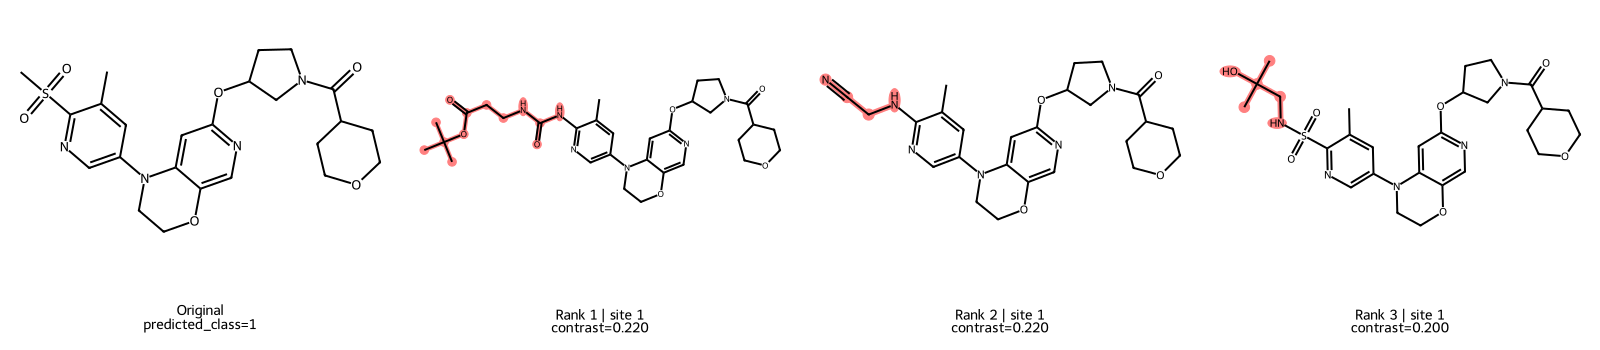

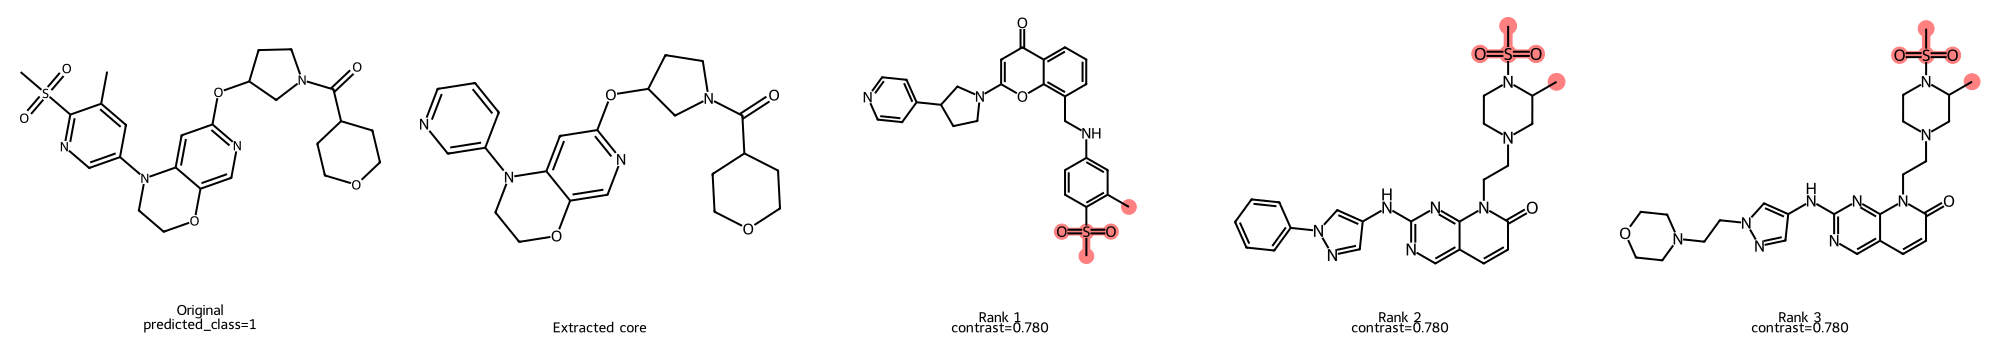

  Status: completed
  Fact class: None, Foil class: 0


In [19]:
# --- RFC ---
print("=" * 60)
print("MolCE single instance — RFC")
print("=" * 60)

# Use the same compound selected earlier for RFC
rfc_molce = explain_with_molce(
    smiles=rfc_compound["smiles"],
    model_path=RFC_MODEL_PATH,
    split_file_path=SPLIT_PATH,
    foil_class=0,
    n_bits=N_BITS,
    radius=RADIUS,
)

for item in rfc_molce:
    if isinstance(item, str):
        parsed = json.loads(item)
        print(f"  Status: {parsed.get('status')}")
        print(f"  Fact class: {parsed.get('fact_class')}, Foil class: {parsed.get('foil_class')}")
        if parsed.get('top_rgroups'):
            print(f"  Top R-groups: {parsed['top_rgroups'][:3]}")
        if parsed.get('top_scaffolds'):
            print(f"  Top scaffolds: {parsed['top_scaffolds'][:3]}")
    else:
        if hasattr(item, 'path') and Path(item.path).exists():
            display(IPyImage(filename=str(item.path)))

In [21]:
# --- All GNN models ---
gnn_molce_results = {}

for gnn_name, gnn_path in gnn_model_paths.items():
    print(f"\n{'=' * 60}")
    print(f"MolCE single instance — {gnn_name}")
    print("=" * 60)
    
    try:
        # Select a correctly predicted compound for this GNN
        compound = select_compound_for_xai(
            split_file_path=SPLIT_PATH,
            model_path=gnn_path,
            target_class=0,
            split="test",
            seed=42,
            gnn_model_class_name=gnn_name,
            gnn_hidden_channels=GNN_HIDDEN,
            gnn_num_classes=NUM_CLASSES,
        )
        print(f"  Selected: {compound['smiles'][:60]}...")
        
        result = explain_with_molce(
            smiles=compound["smiles"],
            model_path=gnn_path,
            split_file_path=SPLIT_PATH,
            foil_class=1,
            n_bits=N_BITS,
            radius=RADIUS,
            gnn_model_class_name=gnn_name,
            gnn_hidden_channels=GNN_HIDDEN,
            gnn_num_classes=NUM_CLASSES,
        )
        gnn_molce_results[gnn_name] = result
        
        for item in result:
            if isinstance(item, str):
                parsed = json.loads(item)
                print(f"  Status: {parsed.get('status')}")
                if parsed.get('top_rgroups'):
                    print(f"  Top R-groups: {parsed['top_rgroups'][:3]}")
                if parsed.get('top_scaffolds'):
                    print(f"  Top scaffolds: {parsed['top_scaffolds'][:3]}")
            else:
                if hasattr(item, 'path') and Path(item.path).exists():
                    display(IPyImage(filename=str(item.path)))
    except Exception as e:
        print(f"  ERROR: {e}")
        gnn_molce_results[gnn_name] = {"status": "failed", "error": str(e)}


MolCE single instance — GCN
  Selected: COc1ncc(-c2ccc3c(c2)COC3)cc1NS(C)(=O)=O...
seen product before
  ERROR: MolCE R-group attribution failed: make_gnn_molce_predict_funcs.<locals>.predict_func_proba() got an unexpected keyword argument 'model'

MolCE single instance — GraphSAGE
  Selected: COc1ncc(-c2ccc3c(c2)COC3)cc1NS(C)(=O)=O...
seen product before
  ERROR: MolCE R-group attribution failed: make_gnn_molce_predict_funcs.<locals>.predict_func_proba() got an unexpected keyword argument 'model'

MolCE single instance — GAT
  Selected: Cc1nc(N)nc(-n2c(Nc3n[nH]c4ccccc34)nc3ccccc32)n1...
seen product before
  ERROR: MolCE R-group attribution failed: make_gnn_molce_predict_funcs.<locals>.predict_func_proba() got an unexpected keyword argument 'model'

MolCE single instance — GC_GNN
  Selected: O=C(Cc1nc(N2CCOCC2)cc(=O)[nH]1)Nc1ccc(Cl)cc1...
  ERROR: MolCE R-group attribution failed: make_gnn_molce_predict_funcs.<locals>.predict_func_proba() got an unexpected keyword argument 'model'

M

---
## 8 — MolCE: recurrent rules (all models)

MolCE recurrent rules — RFC
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before


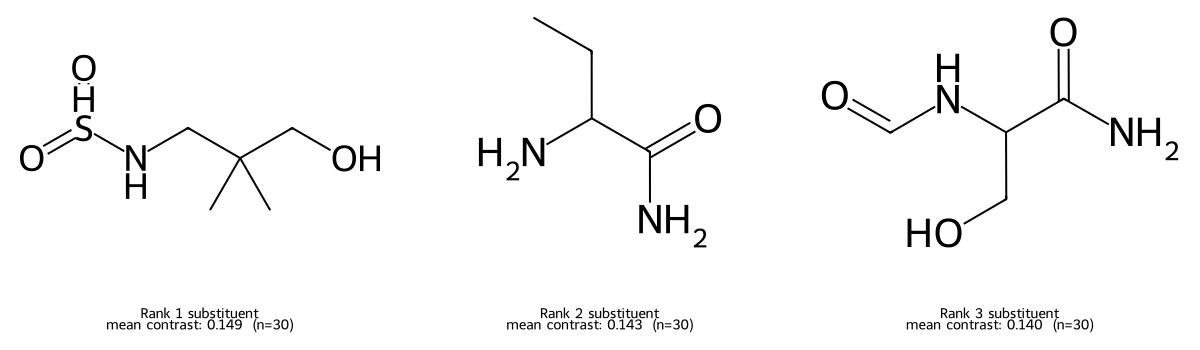

  {
  "fact_class": 1,
  "foil_class": 0,
  "split": "test",
  "compounds_analyzed": 9,
  "compounds_failed": 1,
  "total_rgroup_evaluations": 5529,
  "total_scaffold_evaluations": 705,
  "rgroup_rules": [
    {
      "r_group_smiles": "*S(=O)(=O)NCC(C)(C)CO",
      "mean_contrast": 0.1491564625850339


In [22]:
# --- RFC recurrent MolCE ---
print("=" * 60)
print("MolCE recurrent rules — RFC")
print("=" * 60)

rfc_molce_recurrent = identify_recurrent_molce_rules(
    split_file_path=SPLIT_PATH,
    model_path=RFC_MODEL_PATH,
    fact_class=1,
    foil_class=0,
    split="test",
    n_bits=N_BITS,
    radius=RADIUS,
    max_compounds=10,
)

for item in rfc_molce_recurrent:
    if isinstance(item, str):
        parsed = json.loads(item)
        print(f"  {json.dumps(parsed, indent=2)[:300]}")
    else:
        if hasattr(item, 'path') and Path(item.path).exists():
            display(IPyImage(filename=str(item.path)))

In [24]:
# --- GNN recurrent MolCE ---
gnn_molce_recurrent_results = {}

for gnn_name, gnn_path in gnn_model_paths.items():
    print(f"\n{'=' * 60}")
    print(f"MolCE recurrent rules — {gnn_name}")
    print("=" * 60)
    
    try:
        result = identify_recurrent_molce_rules(
            split_file_path=SPLIT_PATH,
            model_path=gnn_path,
            fact_class=0,
            foil_class=1,
            split="test",
            n_bits=N_BITS,
            radius=RADIUS,
            max_compounds=10,
            gnn_model_class_name=gnn_name,
            gnn_hidden_channels=GNN_HIDDEN,
            gnn_num_classes=NUM_CLASSES,
        )
        gnn_molce_recurrent_results[gnn_name] = result
        
        for item in result:
            if isinstance(item, str):
                parsed = json.loads(item)
                print(f"  {json.dumps(parsed, indent=2)[:300]}")
            else:
                if hasattr(item, 'path') and Path(item.path).exists():
                    display(IPyImage(filename=str(item.path)))
    except Exception as e:
        print(f"  ERROR: {e}")
        gnn_molce_recurrent_results[gnn_name] = {"status": "failed", "error": str(e)}


MolCE recurrent rules — GCN
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen product before
seen produc

KeyboardInterrupt: 

---
## 9 — Counterfactuals: 3 test instances (all models)

In [25]:
from chemagent.explainability.counterfactual_tools import generate_counterfactuals, visualize_counterfactuals

In [27]:
# Select 3 correctly predicted test compounds for RFC
test_smiles = list(split_data["test_smiles"])
test_labels = np.array(split_data["test_labels"])
rfc_test_preds = ml.model.predict(np.array(split_data["test_features"]))
correct_mask = rfc_test_preds == test_labels
correct_indices = np.where(correct_mask)[0]

# Pick 3 compounds from different classes if possible
np.random.seed(42)
selected_indices = []
for cls in sorted(set(test_labels)):
    cls_correct = [i for i in correct_indices if test_labels[i] == cls]
    if cls_correct:
        selected_indices.append(np.random.choice(cls_correct))
    if len(selected_indices) >= 3:
        break
# Fill up to 3 if not enough classes
while len(selected_indices) < 3 and len(correct_indices) > len(selected_indices):
    remaining = [i for i in correct_indices if i not in selected_indices]
    selected_indices.append(np.random.choice(remaining))

CF_QUERY_SMILES = [test_smiles[i] for i in selected_indices]
CF_QUERY_LABELS = [int(test_labels[i]) for i in selected_indices]

for i, (smi, lbl) in enumerate(zip(CF_QUERY_SMILES, CF_QUERY_LABELS)):
    print(f"Query {i+1}: class={lbl}, SMILES={smi[:70]}...")

Query 1: class=0, SMILES=CC(=O)Nc1ncc(-c2nc(N3CCOCC3)c3ncccc3n2)cn1...
Query 2: class=1, SMILES=COCC(=O)N(C)C1CCCN(Cc2cc3nc(-c4cccc5[nH]ccc45)nc(N4CCOCC4)c3s2)C1...
Query 3: class=2, SMILES=CC(Nc1ccc2c(c1)OCCn1cc(N3C(=O)OCC3C(F)F)nc1-2)C(N)=O...


Failed to patch pandas - PandasTools will have limited functionality


Counterfactuals — RFC

  Query 1: CC(=O)Nc1ncc(-c2nc(N3CCOCC3)c3ncccc3n2)cn1...
    Status: completed, predicted_class=0, CFs found=1


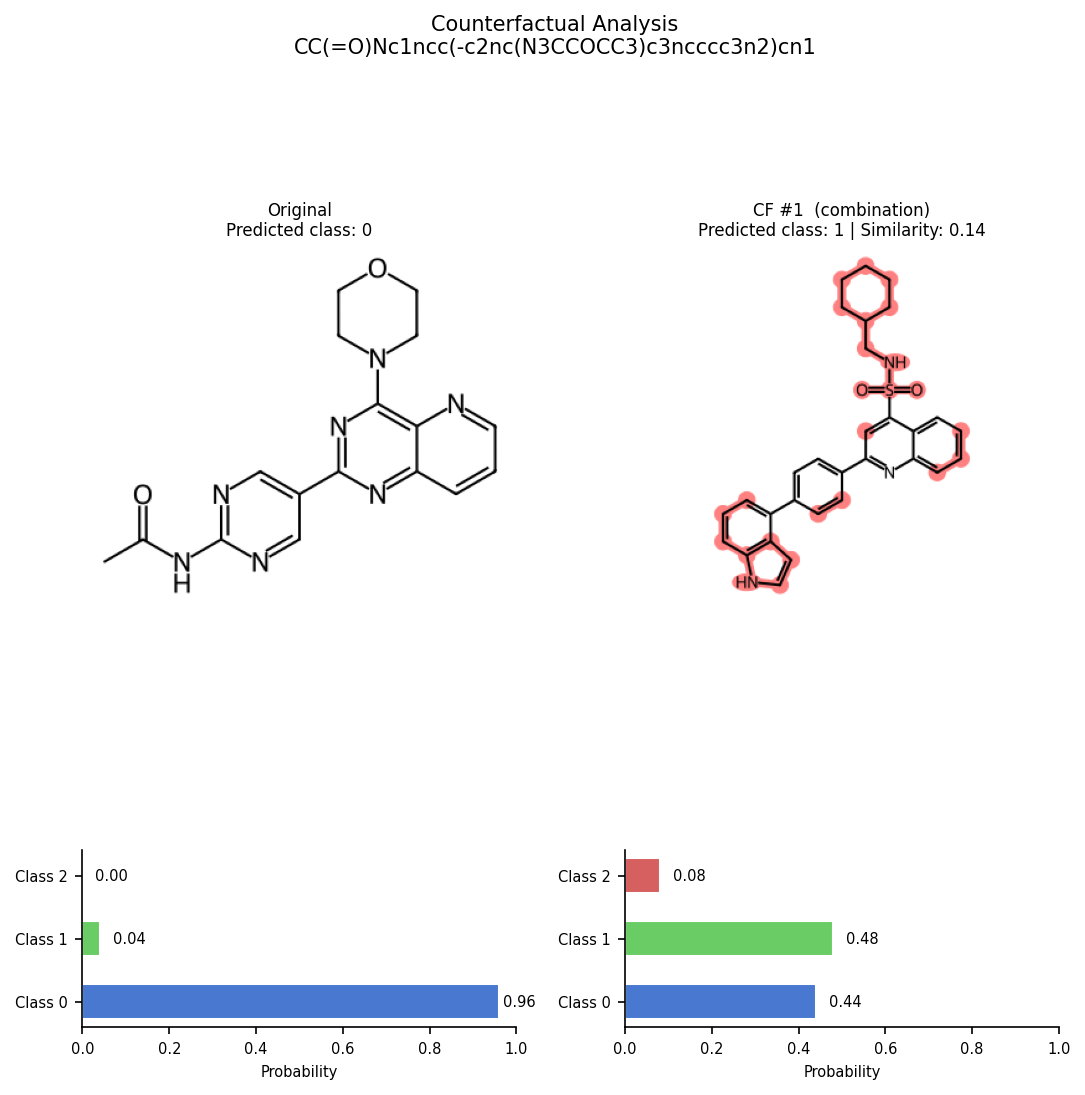


  Query 2: COCC(=O)N(C)C1CCCN(Cc2cc3nc(-c4cccc5[nH]ccc45)nc(N4CCOCC4)c3...
    Status: completed, predicted_class=1, CFs found=5


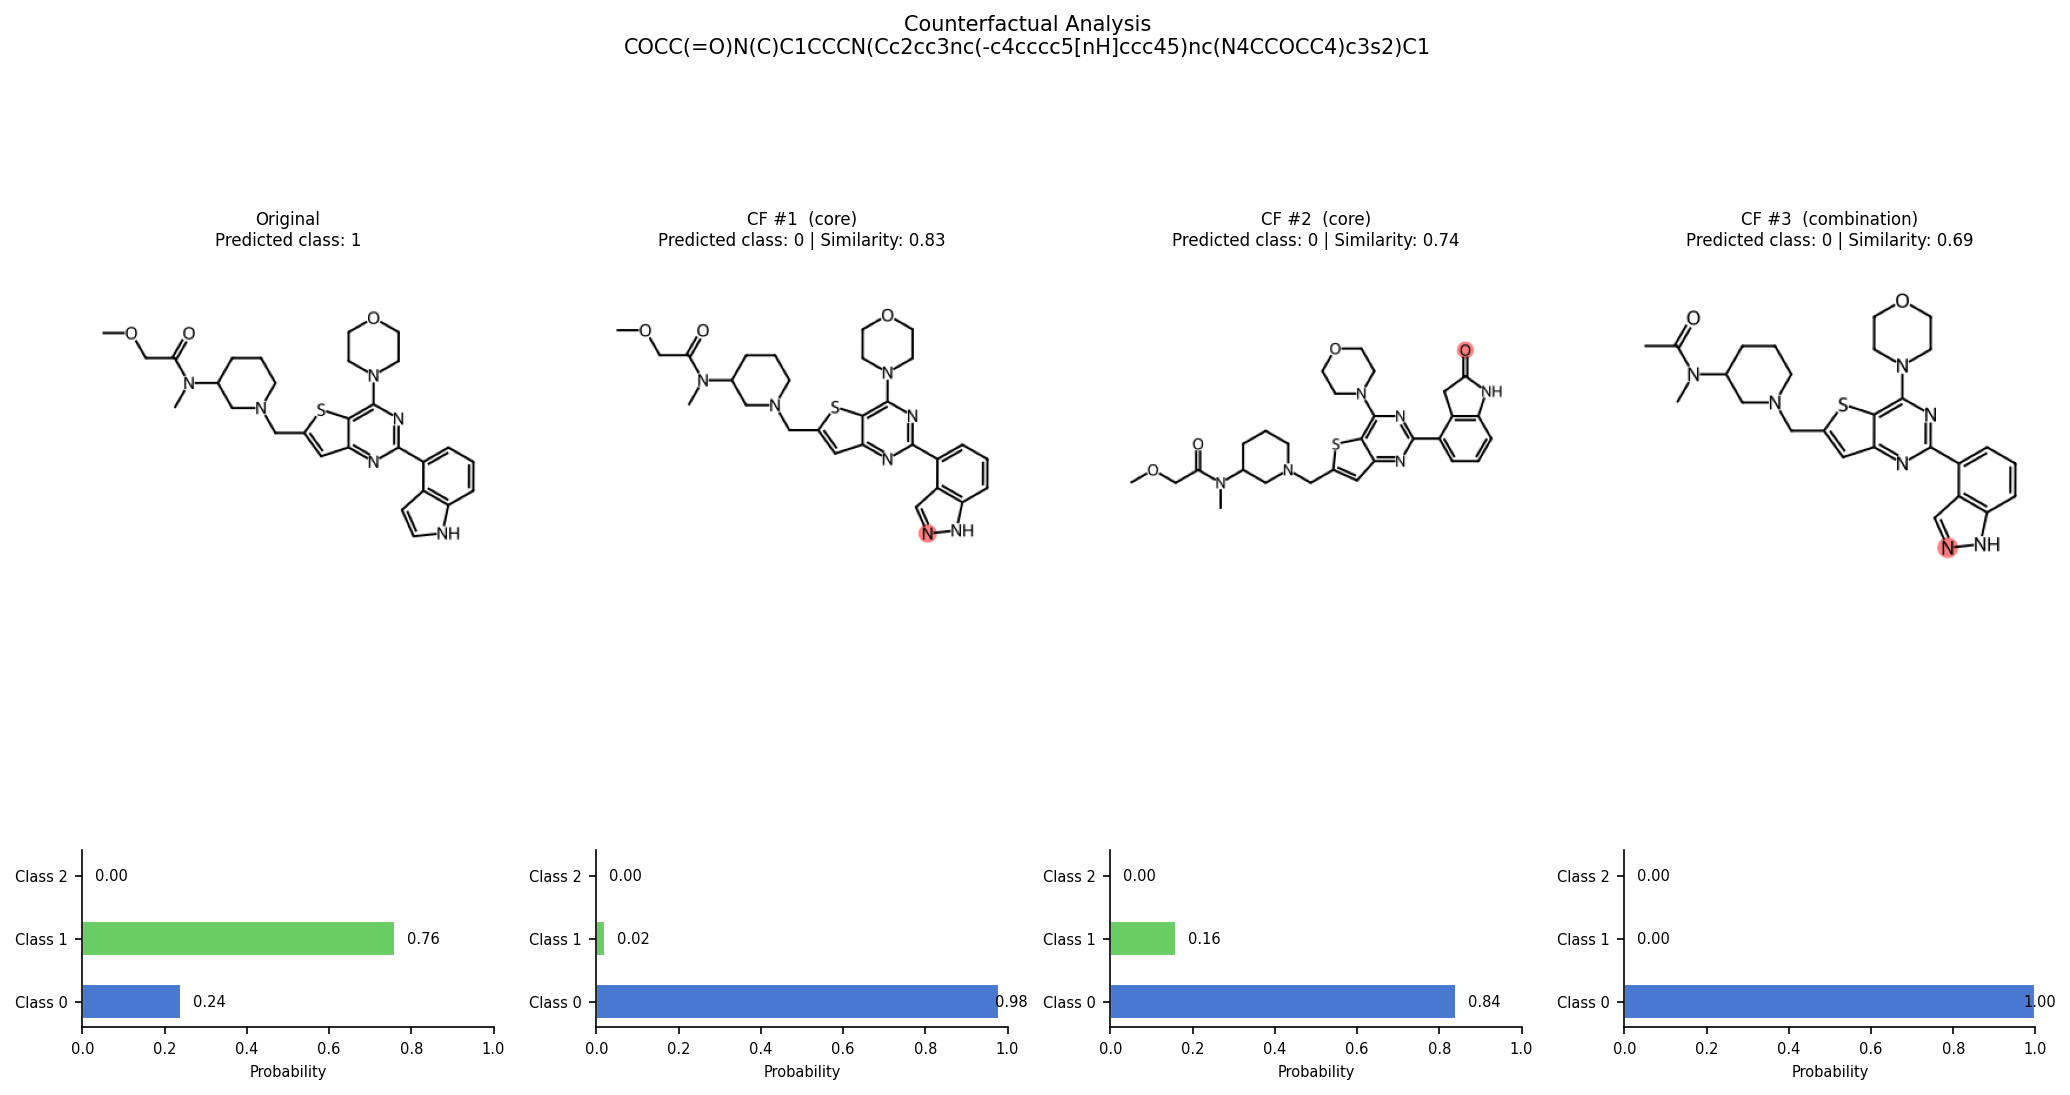


  Query 3: CC(Nc1ccc2c(c1)OCCn1cc(N3C(=O)OCC3C(F)F)nc1-2)C(N)=O...
    Status: completed, predicted_class=2, CFs found=5


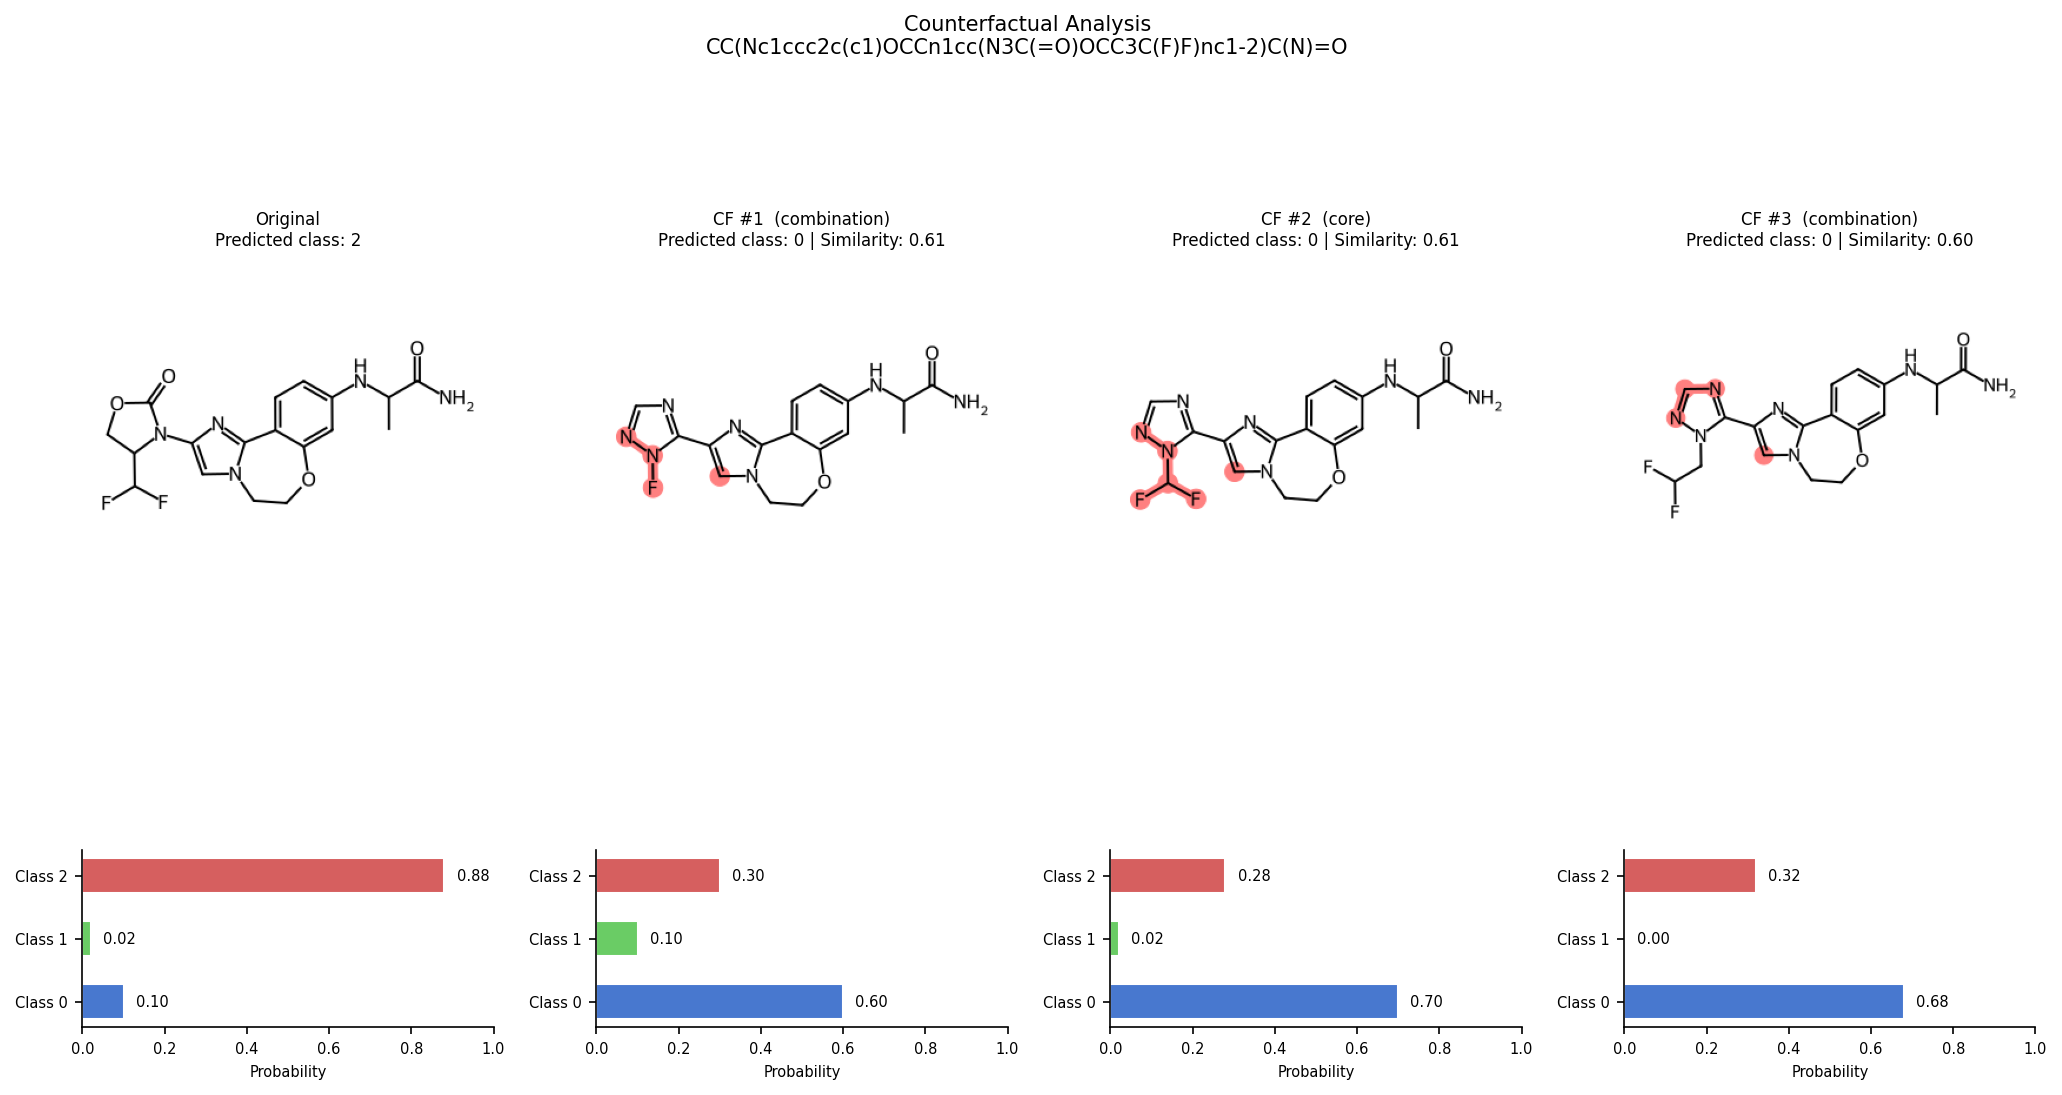

In [28]:
# --- RFC counterfactuals ---
print("=" * 60)
print("Counterfactuals — RFC")
print("=" * 60)

rfc_cf_results = []
for i, query_smi in enumerate(CF_QUERY_SMILES):
    print(f"\n  Query {i+1}: {query_smi[:60]}...")
    try:
        cf_result = generate_counterfactuals(
            query_smiles=query_smi,
            model_path=RFC_MODEL_PATH,
            split_file_path=SPLIT_PATH,
            n_bits=N_BITS,
            radius=RADIUS,
            max_counterfactuals=5,
        )
        rfc_cf_results.append(cf_result)
        print(f"    Status: {cf_result['status']}, "
              f"predicted_class={cf_result['predicted_class']}, "
              f"CFs found={cf_result['num_counterfactuals']}")
        
        if cf_result["num_counterfactuals"] > 0:
            viz = visualize_counterfactuals(cf_result, top_n=3)
            for item in viz:
                if not isinstance(item, str) and hasattr(item, 'path') and Path(item.path).exists():
                    display(IPyImage(filename=str(item.path)))
    except Exception as e:
        print(f"    ERROR: {e}")
        rfc_cf_results.append({"status": "failed", "error": str(e)})

In [30]:
# --- GNN counterfactuals ---
gnn_cf_results = {}

for gnn_name, gnn_path in gnn_model_paths.items():
    print(f"\n{'=' * 60}")
    print(f"Counterfactuals — {gnn_name}")
    print("=" * 60)
    
    model_cfs = []
    for i, query_smi in enumerate(CF_QUERY_SMILES):
        print(f"\n  Query {i+1}: {query_smi[:60]}...")
        try:
            cf_result = generate_counterfactuals(
                query_smiles=query_smi,
                model_path=gnn_path,
                split_file_path=SPLIT_PATH,
                n_bits=N_BITS,
                radius=RADIUS,
                max_counterfactuals=5,
                gnn_model_class_name=gnn_name,
                gnn_hidden_channels=GNN_HIDDEN,
                gnn_num_classes=NUM_CLASSES,
            )
            model_cfs.append(cf_result)
            print(f"    Status: {cf_result['status']}, "
                  f"predicted_class={cf_result['predicted_class']}, "
                  f"CFs found={cf_result['num_counterfactuals']}")
            
            if cf_result["num_counterfactuals"] > 0:
                viz = visualize_counterfactuals(cf_result, top_n=3)
                for item in viz:
                    if not isinstance(item, str) and hasattr(item, 'path') and Path(item.path).exists():
                        display(IPyImage(filename=str(item.path)))
        except Exception as e:
            print(f"    ERROR: {e}")
            model_cfs.append({"status": "failed", "error": str(e)})
    
    gnn_cf_results[gnn_name] = model_cfs


Counterfactuals — GCN

  Query 1: CC(=O)Nc1ncc(-c2nc(N3CCOCC3)c3ncccc3n2)cn1...


KeyboardInterrupt: 

---
## 10 — Summary

In [25]:
print("\nXAI Compatibility Test Summary")
print("=" * 70)

all_models = ["RFC"] + list(GNN_CLASSES.keys())

rows = []
for model_name in all_models:
    row = {"model": model_name}
    
    # MolAnchor single
    if model_name == "RFC":
        row["molanchor_single"] = rfc_anchor_result.get("status", "?")
    else:
        r = gnn_anchor_results.get(model_name, {})
        row["molanchor_single"] = r.get("status", "?")
    
    # MolAnchor recurrent
    if model_name == "RFC":
        # Check if the last item in rfc_recurrent is a summary with status
        try:
            last = json.loads(rfc_recurrent[-1]) if isinstance(rfc_recurrent[-1], str) else {}
            row["molanchor_recurrent"] = last.get("status", "?")
        except Exception:
            row["molanchor_recurrent"] = "?" 
    else:
        r = gnn_recurrent_results.get(model_name, {})
        if isinstance(r, list) and r:
            try:
                last = json.loads(r[-1]) if isinstance(r[-1], str) else {}
                row["molanchor_recurrent"] = last.get("status", "?")
            except Exception:
                row["molanchor_recurrent"] = "?"
        else:
            row["molanchor_recurrent"] = r.get("status", "?") if isinstance(r, dict) else "?"
    
    # MolCE single
    if model_name == "RFC":
        try:
            last = json.loads(rfc_molce[-1]) if isinstance(rfc_molce[-1], str) else {}
            row["molce_single"] = last.get("status", "?")
        except Exception:
            row["molce_single"] = "?"
    else:
        r = gnn_molce_results.get(model_name, {})
        if isinstance(r, list) and r:
            try:
                last = json.loads(r[-1]) if isinstance(r[-1], str) else {}
                row["molce_single"] = last.get("status", "?")
            except Exception:
                row["molce_single"] = "?"
        else:
            row["molce_single"] = r.get("status", "?") if isinstance(r, dict) else "?"
    
    # MolCE recurrent
    if model_name == "RFC":
        try:
            last = json.loads(rfc_molce_recurrent[-1]) if isinstance(rfc_molce_recurrent[-1], str) else {}
            row["molce_recurrent"] = last.get("status", "?")
        except Exception:
            row["molce_recurrent"] = "?"
    else:
        r = gnn_molce_recurrent_results.get(model_name, {})
        if isinstance(r, list) and r:
            try:
                last = json.loads(r[-1]) if isinstance(r[-1], str) else {}
                row["molce_recurrent"] = last.get("status", "?")
            except Exception:
                row["molce_recurrent"] = "?"
        else:
            row["molce_recurrent"] = r.get("status", "?") if isinstance(r, dict) else "?"
    
    # Counterfactuals (3 queries)
    if model_name == "RFC":
        cfs = rfc_cf_results
    else:
        cfs = gnn_cf_results.get(model_name, [])
    
    cf_statuses = []
    for cf in cfs:
        if isinstance(cf, dict):
            s = cf.get("status", "?")
            n = cf.get("num_counterfactuals", 0)
            cf_statuses.append(f"{s}({n})")
    row["counterfactuals"] = " | ".join(cf_statuses) if cf_statuses else "?"
    
    rows.append(row)

summary = pd.DataFrame(rows)
display(summary)


XAI Compatibility Test Summary


NameError: name 'gnn_molce_recurrent_results' is not defined

In [ ]:
print("\nDone! All XAI methods tested across RFC + 5 GNN architectures.")